In [1]:
from google.colab import files
uploaded = files.upload()

Saving Hotel_Reviews.csv to Hotel_Reviews.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SimpleRNN, Dropout

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [4]:
df = pd.read_csv('Hotel_Reviews.csv')

In [5]:
# Labeling: Rating >= 4 is Positive (Label 0), < 4 is Negative (Label 1)
df['Label'] = df['Rating'].apply(lambda x: 0 if x >= 4 else 1)

print("Class Distribution:")
print(df['Label'].value_counts())
df.head()

Class Distribution:
Label
0    15093
1     5398
Name: count, dtype: int64


,Review,Rating,Label
0,nice hotel expensive parking got good deal sta...,4,0
1,ok nothing special charge diamond member hilto...,2,1
2,nice rooms not 4* experience hotel monaco seat...,3,1
3,"unique, great stay, wonderful time hotel monac...",5,0
4,"great stay great stay, went seahawk game aweso...",5,0


In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation and numbers
    tokens = text.split()
    # Remove stopwords and apply lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

print("Cleaning text (this may take a minute)...")
df['Clean_Review'] = df['Review'].apply(clean_text)

# Tokenization and Padding
vocab_size = 10000
max_length = 100
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df['Clean_Review'])

X = tokenizer.texts_to_sequences(df['Clean_Review'])
X = pad_sequences(X, maxlen=max_length, padding='post')
y = df['Label'].values

Cleaning text (this may take a minute)...


In [7]:
# Split data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data ready for training.")

Data ready for training.


In [8]:
# --- 1. Simple RNN (Baseline) ---
model1 = Sequential([
    Embedding(vocab_size, 64, input_length=max_length),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\nTraining Model 1: Simple RNN...")
history1 = model1.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test), batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Training Model 1: Simple RNN...
Epoch 1/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.7346 - loss: 0.5778 - val_accuracy: 0.7429 - val_loss: 0.5634
Epoch 2/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.7503 - loss: 0.5397 - val_accuracy: 0.7399 - val_loss: 0.5603
Epoch 3/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.8055 - loss: 0.4673 - val_accuracy: 0.7575 - val_loss: 0.5744
Epoch 4/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.8430 - loss: 0.3841 - val_accuracy: 0.7519 - val_loss: 0.6067
Epoch 5/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.8533 - loss: 0.3496 - val_accuracy: 0.7336 - val_loss: 0.6729


In [9]:
# --- 2. Standard LSTM (Advanced) ---
model2 = Sequential([
    Embedding(vocab_size, 64, input_length=max_length),
    LSTM(64, dropout=0.2),
    Dense(1, activation='sigmoid')
])
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\nTraining Model 2: Standard LSTM...")
history2 = model2.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test), batch_size=32)


Training Model 2: Standard LSTM...
Epoch 1/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.7358 - loss: 0.5315 - val_accuracy: 0.8170 - val_loss: 0.4590
Epoch 2/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step - accuracy: 0.7482 - loss: 0.4840 - val_accuracy: 0.5140 - val_loss: 0.6833
Epoch 3/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - accuracy: 0.7739 - loss: 0.5048 - val_accuracy: 0.7646 - val_loss: 0.4549
Epoch 4/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 39s 69ms/step - accuracy: 0.8313 - loss: 0.3926 - val_accuracy: 0.8331 - val_loss: 0.4420
Epoch 5/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - accuracy: 0.8098 - loss: 0.4581 - val_accuracy: 0.7995 - val_loss: 0.5371


In [10]:
# --- 3. LSTM with Pre-trained GloVe Embeddings (Transfer Learning) ---
# Download GloVe (Small version)
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

embeddings_index = {}
with open('glove.6B.50d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

embedding_matrix = np.zeros((vocab_size, 50))
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

model3 = Sequential([
    Embedding(vocab_size, 50, weights=[embedding_matrix], input_length=max_length, trainable=False),
    LSTM(64),
    Dense(1, activation='sigmoid')
])
model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\nTraining Model 3: GloVe LSTM...")
history3 = model3.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test), batch_size=32)

--2026-05-12 03:03:00--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-05-12 03:03:00--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-05-12 03:03:00--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

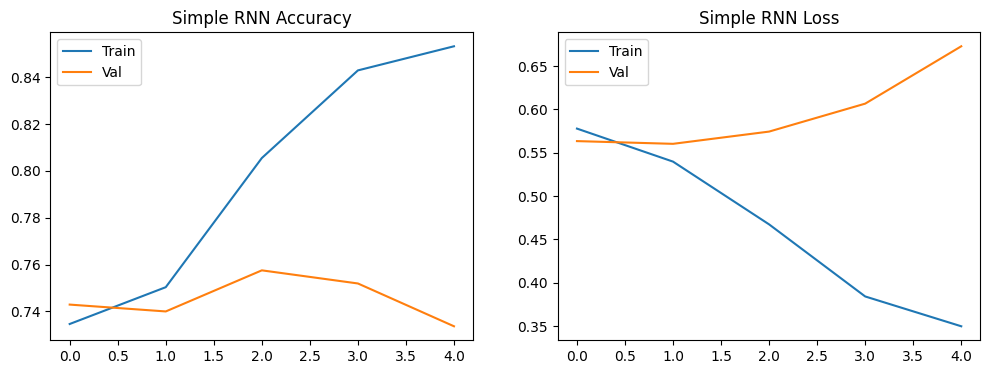

129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step

--- Simple RNN Classification Report ---

              precision    recall  f1-score   support

    Positive       0.80      0.86      0.83      3042
    Negative       0.48      0.38      0.43      1057

    accuracy                           0.73      4099
   macro avg       0.64      0.62      0.63      4099
weighted avg       0.72      0.73      0.72      4099



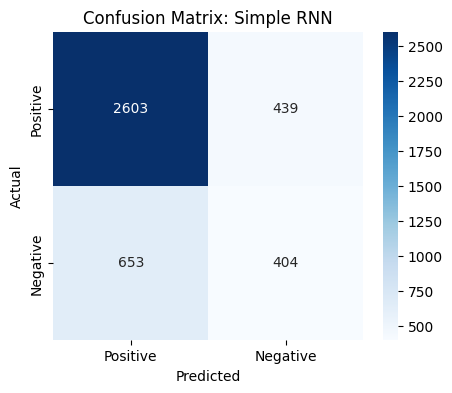

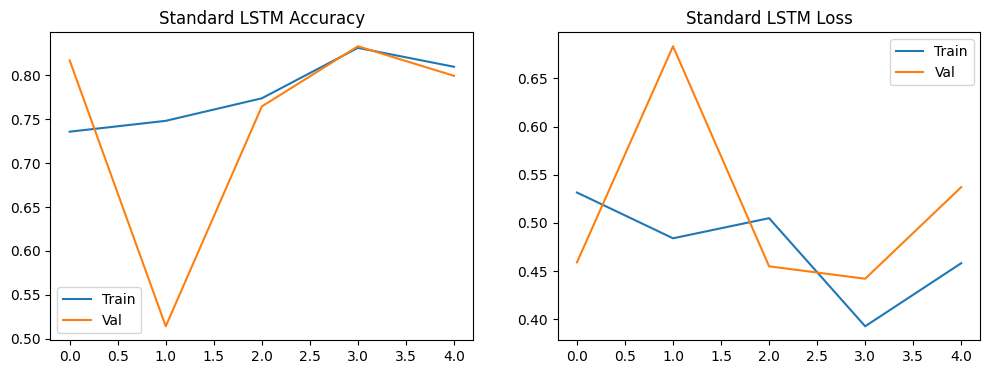

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step

--- Standard LSTM Classification Report ---

              precision    recall  f1-score   support

    Positive       0.88      0.85      0.86      3042
    Negative       0.60      0.66      0.63      1057

    accuracy                           0.80      4099
   macro avg       0.74      0.76      0.75      4099
weighted avg       0.81      0.80      0.80      4099



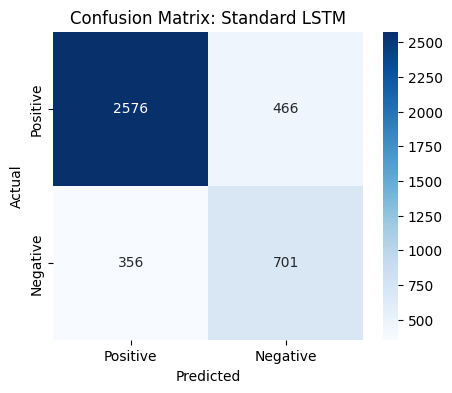

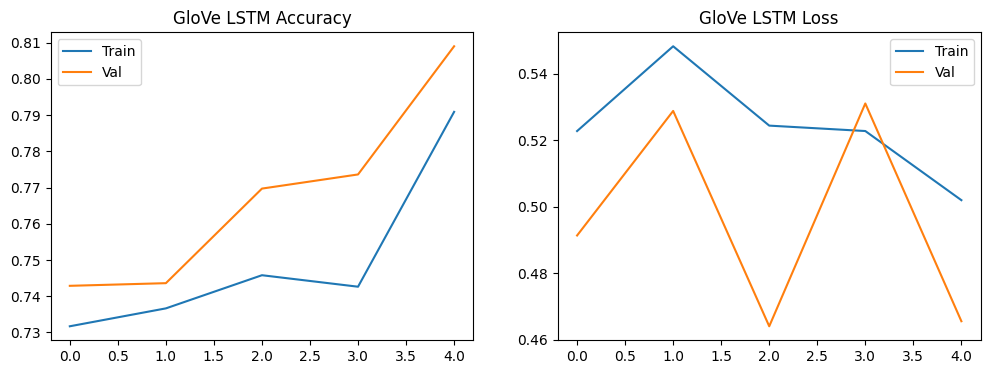

129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step

--- GloVe LSTM Classification Report ---

              precision    recall  f1-score   support

    Positive       0.82      0.96      0.88      3042
    Negative       0.76      0.38      0.51      1057

    accuracy                           0.81      4099
   macro avg       0.79      0.67      0.69      4099
weighted avg       0.80      0.81      0.79      4099



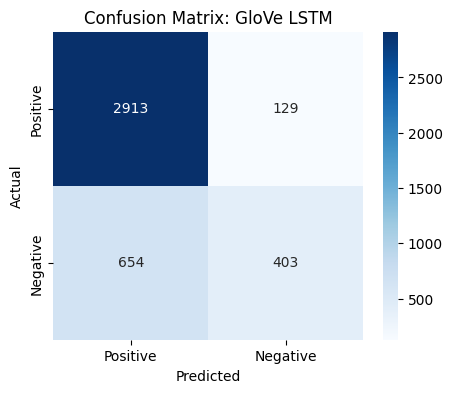

In [13]:
def plot_evaluation(model, history, name):
    # Plot Accuracy and Loss
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Val')
    ax1.set_title(f'{name} Accuracy')
    ax1.legend()

    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Val')
    ax2.set_title(f'{name} Loss')
    ax2.legend()
    plt.show()

    # Classification Report
    y_pred = (model.predict(X_test) > 0.5).astype("int32")
    print(f"\n--- {name} Classification Report ---\n")
    print(classification_report(y_test, y_pred, target_names=['Positive', 'Negative']))

    # Confusion Matrix
    plt.figure(figsize=(5,4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Generate results for all models
plot_evaluation(model1, history1, "Simple RNN")
plot_evaluation(model2, history2, "Standard LSTM")
plot_evaluation(model3, history3, "GloVe LSTM")